In [1]:
!pip install openai

In [2]:
def read_lines(filepath):
    # Legge le linee da un file saltanto le righe vuote
    with open(filepath, 'r', encoding='utf-8') as f:
        return [line.strip() for line in f.readlines() if line.strip()]

def read_labels(filepath):
    # Legge le etichette intere da un file saltando le righe vuote
    with open(filepath, 'r', encoding='utf-8') as f:
        return [int(line.strip()) for line in f.readlines() if line.strip()]

In [3]:
import pandas as pd

# File paths
train_text_path = "emotion/train_text.txt"
train_labels_path = "emotion/train_labels.txt"
mapping_path = "emotion/mapping.txt"

# Load base training data
train_texts = read_lines(train_text_path)
train_labels = read_labels(train_labels_path)

mapping = pd.read_csv(mapping_path, header=None, index_col=0, sep="\t")[1].to_dict()

Distribuzione delle classi nel training set (originale):
0    1400
1     708
2     294
3     855
Name: count, dtype: int64


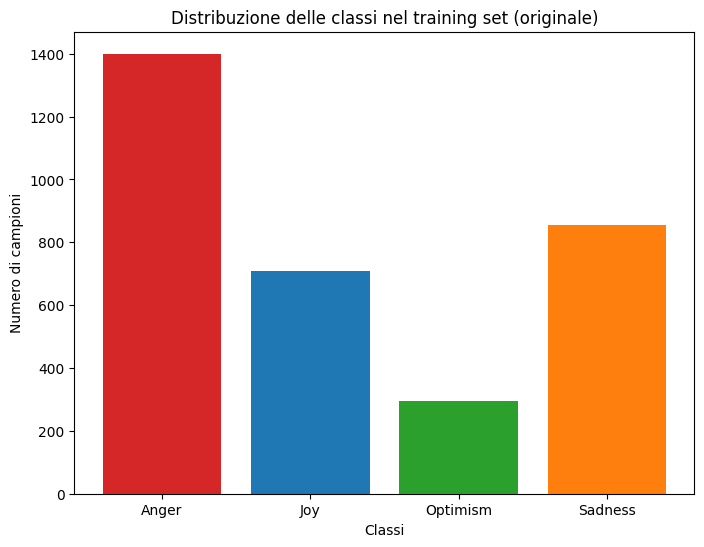


Campioni da aggiungere per ciascuna classe:
Classe 0 (Anger): 0
Classe 1 (Joy): 346
Classe 2 (Optimism): 294
Classe 3 (Sadness): 272

Totale augmentation tasks da processare: 912

Distribuzione delle classi dopo augmentation:
0    1400
1    1054
2     588
3    1127
Name: count, dtype: int64


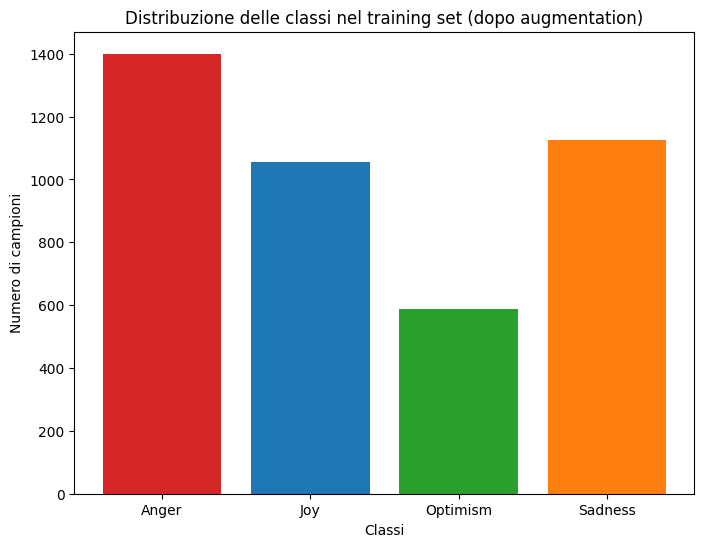

In [4]:
import pandas as pd
import random
import matplotlib.pyplot as plt

# Supponiamo che train_labels sia già definito
# Esempio (da sostituire con i tuoi dati):
# train_labels = [0]*200 + [1]*150 + [2]*100 + [3]*170

# Creiamo una Series dai label originali
labels_series = pd.Series(train_labels)

# Calcoliamo la distribuzione originale (ordinata per indice)
class_distribution = labels_series.value_counts().sort_index()
print("Distribuzione delle classi nel training set (originale):")
print(class_distribution)

# Definiamo i nomi delle classi, nell’ordine degli indici 0,1,2,3.
label_names = ['Anger', 'Joy', 'Optimism', 'Sadness']

# Estraiamo i conteggi per ciascuna classe
counts = [class_distribution.get(i, 0) for i in range(len(label_names))]

# Plot della distribuzione originale
plt.figure(figsize=(8, 6))
plt.bar(label_names, counts, color=['tab:red', 'tab:blue', 'tab:green', 'tab:orange'])
plt.xlabel("Classi")
plt.ylabel("Numero di campioni")
plt.title("Distribuzione delle classi nel training set (originale)")
plt.show()

# Augmentation con limite massimo del doppio del conteggio originale
max_count = class_distribution.max()
augmentation_rate = 0.5  # Aggiungiamo il 50% della differenza

# Calcoliamo il numero massimo di campioni che possiamo aggiungere per classe
augmentation_per_class = {}
for label, count in class_distribution.items():
    if count == max_count:
        augmentation = 0  # Non aumentiamo la classe più numerosa
    else:
        max_allowed = count * 2  # Limite massimo per augmentation
        augmentation = round(augmentation_rate * (max_count - count))
        augmentation = min(augmentation, max_allowed - count)  # Non superiamo il doppio
    augmentation_per_class[label] = augmentation

print("\nCampioni da aggiungere per ciascuna classe:")
for label, aug_count in augmentation_per_class.items():
    print(f"Classe {label} ({label_names[label] if label < len(label_names) else label}): {aug_count}")

# Selezione dei campioni per l'augmentation
augmentation_tasks = []
for label, aug_count in augmentation_per_class.items():
    indices = [i for i, lab in enumerate(train_labels) if lab == label]
    if not indices or aug_count <= 0:
        continue
    if aug_count > len(indices):
        selected_indices = random.choices(indices, k=aug_count)
    else:
        selected_indices = random.sample(indices, aug_count)
    for idx in selected_indices:
        augmentation_tasks.append((idx, label))

print(f"\nTotale augmentation tasks da processare: {len(augmentation_tasks)}")

# Simuliamo l’augmentation
augmented_labels = train_labels + [label for _, label in augmentation_tasks]

# Distribuzione dopo augmentation
aug_labels_series = pd.Series(augmented_labels)
aug_class_distribution = aug_labels_series.value_counts().sort_index()
print("\nDistribuzione delle classi dopo augmentation:")
print(aug_class_distribution)

aug_counts = [aug_class_distribution.get(i, 0) for i in range(len(label_names))]
plt.figure(figsize=(8, 6))
plt.bar(label_names, aug_counts, color=['tab:red', 'tab:blue', 'tab:green', 'tab:orange'])
plt.xlabel("Classi")
plt.ylabel("Numero di campioni")
plt.title("Distribuzione delle classi nel training set (dopo augmentation)")
plt.show()


In [5]:
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
model_for_embeddings = SentenceTransformer("digio/Twitter4SSE")
def is_similar(original_tweet, paraphrased_tweet, model=model_for_embeddings):
  embedding_tweet = model.encode(original_tweet, convert_to_tensor=False).reshape(1, -1)
  embedding_paraphrased_tweet = model.encode(paraphrased_tweet, convert_to_tensor=False).reshape(1, -1)

  c_similarity = cosine_similarity(embedding_tweet, embedding_paraphrased_tweet)[0][0]

  if c_similarity >= 0.75:
    return True, c_similarity

  return False, c_similarity

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/755 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/540M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/359 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/843k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/540M [00:00<?, ?B/s]

bpe.codes:   0%|          | 0.00/1.08M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/17.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0


In [ ]:
from openai import OpenAI
import time

# Inizializza il client con la chiave API di DeepSeek
client = OpenAI(api_key="sk-****", base_url="https://api.deepseek.com")

def paraphrase_tweet(label, tweet, temperature=0.7):
    # Costruisci il prompt con gli esempi
    messages = [
        {
            "role": "system",
            "content": (
                "You are an AI assistant specialized in paraphrasing tweets while preserving their original emotion, meaning, and context. "
                "Your task is to rephrase tweets using different wording, synonyms, and sentence structures without altering the core sentiment or key details. "
                "Your response must contain only the paraphrased tweet, with no additional explanations, notes, or comments. "
                "Pay special attention to maintaining the specified emotional tone (e.g., Joy, Optimism, Sadness)."
            )
        },
        {
            "role": "user",
            "content": f"""Below are some examples of how to transform tweets without changing their emotional tone:
                Example 1:
                Label: Joy
                Original tweet: Just got surprise tickets to my favorite band’s concert! Best day ever! 🎶🥳
                Paraphrased tweet: I can't believe it! I just got surprise tickets to see my favorite band live! 🎸🎉

                Example 2:
                Label: Optimism
                Original tweet: Some days just feel extra heavy, and that's okay. Just wish it didn’t have to be today.
                Paraphrased tweet: There are days that feel overwhelming, and today is definitely one of them.

                Example 3:
                Label: Sadness
                Original tweet: Success is not final, failure is not fatal: it is the courage to continue that counts.” – Winston Churchill 💪 #motivation
                Paraphrased tweet: Success isn't the end, failure isn't the worst—what truly matters is having the courage to keep going. 💪 #motivation

                Now, please generate a paraphrase for the tweet below while preserving its original emotion:

                Label: {label}
                Original tweet: {tweet}
                Paraphrased tweet:"""
        }
    ]
    while True:
        try:
            response = client.chat.completions.create(
                model="deepseek-chat",
                messages=messages,
                temperature=temperature,
                max_tokens=256,
                top_p=0.9,
                stream=False
            )
            result = response.choices[0].message.content.strip()
            result = result.replace("\n", "\\n")  # Mantiene i "\n" inline invece di interpretarli
            if result.startswith('"') and result.endswith('"'):
                result = result[1:-1]

            # Calcola la similarità tra il tweet originale e la parafrasi generata
            similar, similarity = is_similar(tweet, result)
            print(f"Similarity: {similarity}")
            return result
        except Exception as e:
            print(f" Errore nella parafrasi: {e}. Riprovo dopo una pausa.")
            time.sleep(1)

        # Aumenta la temperatura per il prossimo tentativo


In [7]:
# Esempio di utilizzo
tweet_originale = "I'm so excited for my trip! It's going to be an unforgettable experience!"
label = "Joy"

parafrasi = paraphrase_tweet(label, tweet_originale)
_ , similarity = is_similar(tweet_originale, parafrasi)
print(parafrasi, similarity)

Similarity: 0.9078540802001953
I can't wait for my upcoming adventure! This trip is going to be absolutely amazing and something I'll cherish forever! 🌟✈️ 0.9078541


In [8]:
import random
# Seleziona le categorie di interesse (corrispondenti alle chiavi del mapping)
# In questo caso, vogliamo le categorie 1, 2 e 3
categorie_di_interesse = [1, 2, 3]

# Dizionario per salvare i campioni selezionati per ciascuna categoria
campioni_per_categoria = {}

for cat in categorie_di_interesse:
    # Trova gli indici degli esempi appartenenti alla categoria 'cat'
    indici = [i for i, label in enumerate(train_labels) if label == cat]

    if len(indici) < 3:
        print(f"Attenzione: la categoria {mapping[cat]} ha solo {len(indici)} campioni.")
        indici_selezionati = indici
    else:
        indici_selezionati = random.sample(indici, 3)

    # Estrai i testi corrispondenti agli indici selezionati
    campioni = [train_texts[i] for i in indici_selezionati]
    # Usa il nome della categoria (es. "joy") come chiave nel dizionario
    campioni_per_categoria[mapping[cat]] = campioni

# Stampa i campioni selezionati per ciascuna categoria
for cat_name, campioni in campioni_per_categoria.items():
    print(f"\nCategoria {cat_name}:")
    for sample in campioni:
        print(sample)


Categoria joy:
Vincent looking super lively boy... Hattrick perhaps lol
Today I answered a call from a college rep who didn't realize I did, and I got to hear part of his lively debate about if evolution is real.
We so elated, we celebrated like Obama waited until his last day in office to tell the nation, brothers is getting their reparations

Categoria optimism:
@user SPARKLES, proud little huff. Still posing mind you.
The focal points of war lie in #terrorism and the #UN needs to address #violentextremism
don't give someone power by letting their words offend you

Categoria sadness:
@user I fell and heard a snap hffffhj
@user @user what I miss?
need to sta dating again.I m bored #redheadteen #boldandbeautiful #lost #500aday single men dating Schkeuditz


In [9]:
temperatures = [0, 0.3, 0.5]

for temp in temperatures:
    print("\n========== Temperature:", temp, "==========")
    for class_name, samples in campioni_per_categoria.items():
        print("\n----- Classe:", class_name, "-----")
        for sample in samples:
            paraphrased = paraphrase_tweet(class_name, sample, temperature=temp)
            print("Tweet originale:")
            print(sample)
            print("Tweet parafrasato:")
            print(paraphrased)
            print("---------------------------")


========== Temperature: 0 ==========

----- Classe: joy -----
Similarity: 0.803846001625061
Tweet originale:
Vincent looking super lively boy... Hattrick perhaps lol
Tweet parafrasato:
Vincent’s full of energy today... Maybe a hattrick is on the way, haha!
---------------------------
Similarity: 0.95380699634552
Tweet originale:
Today I answered a call from a college rep who didn't realize I did, and I got to hear part of his lively debate about if evolution is real.
Tweet parafrasato:
Today, I picked up a call from a college rep who didn’t notice I was listening, and I got to catch a snippet of his spirited argument about whether evolution is real!
---------------------------
Similarity: 0.840134859085083
Tweet originale:
We so elated, we celebrated like Obama waited until his last day in office to tell the nation, brothers is getting their reparations
Tweet parafrasato:
We’re overjoyed and celebrating like it’s the best news ever—like Obama saved the biggest announcement for his fin

In [ ]:
import random
from tqdm import tqdm
# Scegliamo dai risultati ottenuti 0 come temperatura migliore
# File di output (usati per scrivere i tweet parafrasati e le label)
train_aug_text_path   = "train_text_aug.txt"
train_aug_labels_path = "train_labels_aug.txt"

with open(train_aug_text_path, "a", encoding="utf-8") as f_text, \
     open(train_aug_labels_path, "a", encoding="utf-8") as f_labels:

    for idx, label_int in tqdm(augmentation_tasks, desc="Paraphrasing Tweets", unit="tweet"):
        tweet = train_texts[idx]
        label_str = mapping.get(label_int, str(label_int))

        paraphrased = paraphrase_tweet(label_str, tweet,temperature=0)
        print(f"Original tweet: {tweet}")
        print(f"Paraphrased tweet: {paraphrased}")
        f_text.write(paraphrased + "\n")
        f_text.flush()
        f_labels.write(str(label_int) + "\n")
        f_labels.flush()


Paraphrasing Tweets:   0%|          | 1/912 [00:26<6:38:58, 26.28s/tweet]

Similarity: 0.9235544204711914
Original tweet: Watch this amazing live.ly broadcast by @user #lively #musically
Paraphrased tweet: Check out this incredible live.ly stream by @user! 🎥✨ #lively #musically


Paraphrasing Tweets:   0%|          | 2/912 [00:36<4:14:58, 16.81s/tweet]

Similarity: 0.946481466293335
Original tweet: @user bts' 화양연화 trilogy MV is my all time fav🙌 quite gloomy but beautiful as well✨
Paraphrased tweet: @user BTS' 화양연화 trilogy MV is my absolute favorite! 🙌 It has such a melancholic yet stunning vibe. ✨


Paraphrasing Tweets:   0%|          | 3/912 [00:49<3:48:00, 15.05s/tweet]

...

Similarity: 0.9354029297828674
Original tweet: #BB18 Michelle crying  again #shocking #bitter He's  just not that into you 😢#TeamNicole
Paraphrased tweet: #BB18 Michelle is in tears once more #shocking #heartbreaking He just doesn’t feel the same way 😢 #TeamNicole


Paraphrasing Tweets: 100%|█████████▉| 911/912 [2:54:10<00:10, 10.10s/tweet]

Similarity: 0.9114698171615601
Original tweet: I feel like singing the song human sadness by Julian Cassablancas and The Voidz or some other sad music. #depression #sad #sadness
Paraphrased tweet: I’m in the mood to play "Human Sadness" by Julian Casablancas and The Voidz or maybe some other melancholic tunes. #depression #sad #sadness


Paraphrasing Tweets: 100%|██████████| 912/912 [2:54:16<00:00, 11.47s/tweet]

Similarity: 0.8358508348464966
Original tweet: oh, btw - after a 6 month depression-free time I got a relapse now... superb
Paraphrased tweet: Just wanted to mention—after six months without depression, I’ve had a relapse. Fantastic.
